In [1]:
print("hello")

hello


(5, 2)
(5,)
(1, 2)


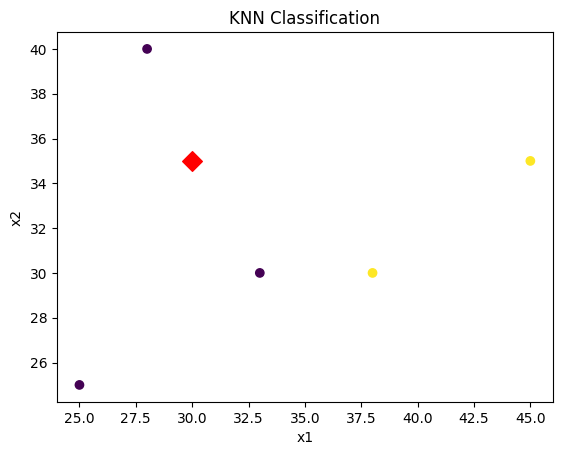

[[-1.23272999 -1.37281295]
 [-0.11206636 -0.39223227]
 [ 0.58834841 -0.39223227]
 [ 1.56892908  0.58834841]
 [-0.81248113  1.56892908]]
[[-0.53231522  0.58834841]]


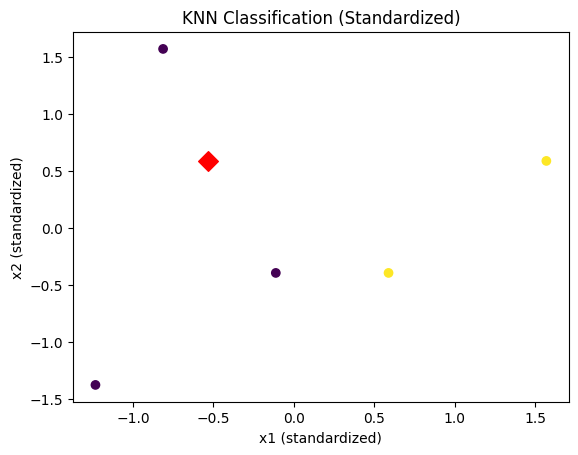

[0]
[[0.66666667 0.33333333]]
[[1.0198193  1.06683999 1.48910222]]
[[4 1 2]]


In [12]:
from sklearn.neighbors import KNeighborsClassifier
# 컬럼별 피처의 스케일이 다르므로 표준화 작업이 필요함 이를 위해 StandardScaler 클래스를 사용하여 표준화 작업을 수행(이전에 사용한 MinMaxScaler도 같은 목적임)
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 로드
# shape: (5, 2) -> 5개의 샘플과 2개의 피처(특성)로 구성된 데이터셋
x_train = np.array([[25, 25],
                    [33, 30],
                    [38, 30],
                    [45, 35],
                    [28, 40]])
# labels
y_train = np.array([0, 0, 1, 1, 0])
print(x_train.shape)
print(y_train.shape)

x_test = np.array([[30, 35]])
print(x_test.shape)

# scatter로 뿌려보거나 판다스로 데이터프레임으로 만들어서 시각화해보면 좋음
# 데이터 시각화(산포도)
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
# x축은 첫 번째 피처, y축은 두 번째 피처, c는 클래스 레이블에 따라 색상을 지정
plt.scatter(x_test[:, 0], x_test[:, 1], c='red', marker='D', s=100)  # 테스트 데이터는 빨간색 X로 표시
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('KNN Classification')
plt.show()

# 표준화 작업
scalerX = StandardScaler()
scalerX.fit(x_train)  # 훈련 데이터로 스케일러를 학습
x_train_std = scalerX.transform(x_train)  # 훈련 데이터를 표준화
print(x_train_std)

x_test_std = scalerX.transform(x_test)  # 테스트 데이터도 같은 스케일러로 표준화
print(x_test_std)

# 그래픽으로 시각화
plt.scatter(x_train_std[:, 0], x_train_std[:, 1], c=y_train)
plt.scatter(x_test_std[:, 0], x_test_std[:, 1], c='red', marker='D', s=100)  # 테스트 데이터는 빨간색 X로 표시
plt.xlabel('x1 (standardized)')
plt.ylabel('x2 (standardized)')
plt.title('KNN Classification (Standardized)')
plt.show()
# metric='euclidean'은 유클리드 거리를 사용하여 이웃 간의 거리를 계산하도록 지정하는 매개변수입니다. 유클리드 거리는 두 점 사이의 직선 거리를 측정하는 방법으로, KNN 알고리즘에서 가장 일반적으로 사용되는 거리 측정 방법 중 하나입니다. 이를 통해 모델이 각 데이터 포인트와 이웃 간의 거리를 계산하여 분류를 수행할 수 있습니다.
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')  # KNN 모델 생성, 이웃의 수는 3, 거리 측정 방법은 유클리드 거리
knn.fit(x_train_std, y_train)  # 모델 훈련

pred = knn.predict(x_test_std)  # 테스트 데이터에 대한 예측
print(pred)  # 예측 결과 출력

print(knn.predict_proba(x_test_std))  # 각 클래스에 대한 예측 확률 출력
# 딥러닝에서는 argmax, argmin을 사용하여 가장 높은 확률을 가진 클래스를 선택하는 경우가 많지만, KNN에서는 predict 메서드가 이미 가장 가까운 이웃의 클래스 레이블을 반환하므로, predict_proba 메서드를 사용하여 각 클래스에 대한 예측 확률을 확인할 수 있습니다.

dist, index = knn.kneighbors(x_test_std)  # 테스트 데이터와 가장 가까운 이웃의 거리와 인덱스 출력
print(dist)  # 거리 출력
print(index)  # 인덱스 출력

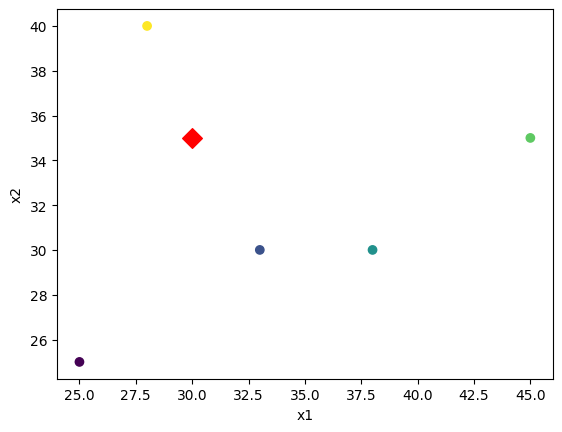

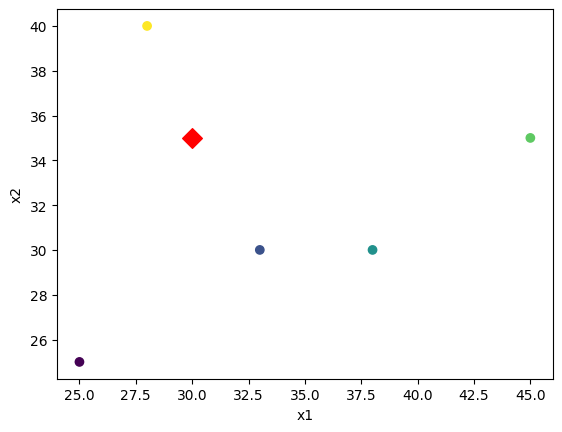

[[-1.23272999 -1.37281295]
 [-0.11206636 -0.39223227]
 [ 0.58834841 -0.39223227]
 [ 1.56892908  0.58834841]
 [-0.81248113  1.56892908]]
[[-1.41421356]
 [-0.70710678]
 [ 0.        ]
 [ 0.70710678]
 [ 1.41421356]]


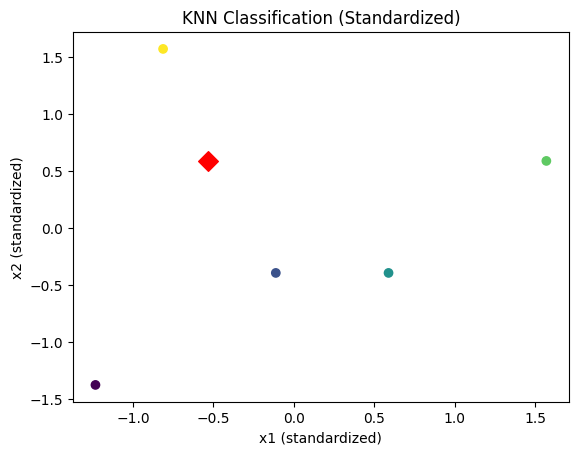

[[0.27956597]]
[[33.95365985]]


In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([[25, 25],
                    [33, 30],
                    [38, 30],
                    [45, 35],
                    [28, 40]])
# labels
y_train = np.array([[10], [20], [30], [40], [50]])

x_test = np.array([[30, 35]])

plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
plt.scatter(x_test[:, 0], x_test[:, 1], c='red', marker='D', s=100)  # 테스트 데이터는 빨간색 X로 표시
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

scalerX = StandardScaler()
scalerX.fit(x_train)  # 훈련 데이터로 스케일러를 학습
x_train_std = scalerX.transform(x_train)  # 훈련 데이터를 표준화
print(x_train_std)

scalerY = StandardScaler()
scalerY.fit(y_train)  # 훈련 데이터로 스케일러를
y_train_std = scalerY.transform(y_train)  # 훈련 데이터를 표준화
print(y_train_std)

# 그래픽으로 시각화
plt.scatter(x_train_std[:, 0], x_train_std[:, 1], c=y_train)
plt.scatter(x_test_std[:, 0], x_test_std[:, 1], c='red', marker='D', s=100)  # 테스트 데이터는 빨간색 X로 표시
plt.xlabel('x1 (standardized)')
plt.ylabel('x2 (standardized)')
plt.title('KNN Classification (Standardized)')
plt.show()

knn = KNeighborsRegressor(n_neighbors=3, metric='euclidean', weights='distance')  # KNN 회귀 모델 생성
#weights를 distance로 설정하면 가까운 이웃에게 더 높은 가중치를 부여하여 예측을 수행합니다. 이는 KNN 회귀에서 일반적으로 사용되는 방법 중 하나입니다. weights='uniform'은 모든 이웃에게 동일한 가중치를 부여하는 반면, weights='distance'는 거리에 따라 가중치를 다르게 부여하여 예측의 정확성을 높일 수 있습니다.
knn.fit(x_train_std, y_train_std)  # 모델 훈련

y_pred = knn.predict(x_test_std)  # 테스트 데이터에 대한 예측
print(y_pred)  # 예측 결과 출력

y_pred_inverse = scalerY.inverse_transform(y_pred)  # 예측 결과를 원래 스케일로 되돌림
print(y_pred_inverse)  # 원래 스케일로 된 예측 결과 출력


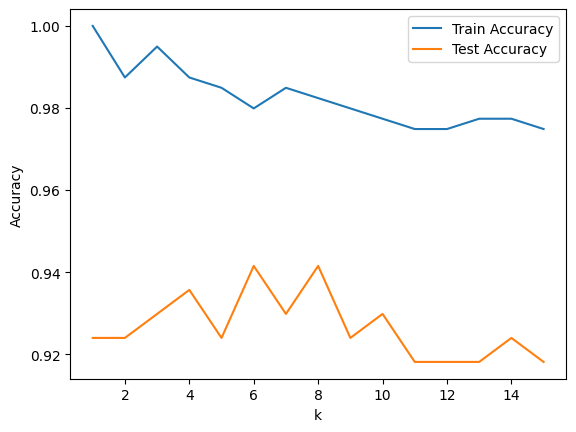

[0.9239766081871345, 0.9239766081871345, 0.9298245614035088, 0.935672514619883, 0.9239766081871345, 0.9415204678362573, 0.9298245614035088, 0.9415204678362573, 0.9239766081871345, 0.9298245614035088, 0.9181286549707602, 0.9181286549707602, 0.9181286549707602, 0.9239766081871345, 0.9181286549707602]
[1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1
 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 0
 1 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0
 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 0 1
 0 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0]
[[ 56  10]
 [  0 105]]
0.9545454545454546


In [38]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = load_breast_cancer(as_frame=True)
# print(data.frame)

# print(data.data)
# print(data.target)

# print(data.DESCR)

# print(data.feature_names)
# print(data.target_names)

data_mean = data.frame[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']]
# sns.pairplot(data_mean, hue='target')

x_train,x_test,y_train,y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=1234)
# print(x_train.shape)
# print(y_train.shape)
# print(x_test.shape)
# print(y_test.shape)

scaleX = StandardScaler()
scaleX.fit(x_train)
X_train_std = scaleX.transform(x_train)
X_test_std = scaleX.transform(x_test)
# print(X_train_std)
# print(X_test_std)

train_accuracy = []
test_accuracy = []

neighbors = range(1, 16)
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    score =knn.score(X_train_std, y_train)
    train_accuracy.append(score)
    score = knn.score(X_test_std, y_test)
    test_accuracy.append(score)

plt.plot(neighbors, train_accuracy, label='Train Accuracy')
plt.plot(neighbors, test_accuracy, label='Test Accuracy')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print(test_accuracy)
k = 6
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_std, y_train)
y_pred = knn.predict(X_test_std)
print(y_pred)

cf = confusion_matrix(y_test, y_pred)
print(cf)

knn.score(X_test_std, y_test)

#f1 score 계산
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)
